# Notebook 04 — Train the Safety Classifier (Model 1)

**Capstone proposal reference:** Section 3.6 — *"Safety / Moderation Layer: Output is passed through a content moderation classifier."*  
**Algorithms compared:** Logistic Regression, SVM, XGBoost, Multi-Layer Perceptron (matches Section 3.4 of the proposal).

## What this model does
Binary classifier: given a user query (English or Kinyarwanda), predict whether it is **safe** to process through the RAG pipeline or **unsafe** and should be blocked + replaced with a helpline referral.

## Why this model matters most
The platform serves minors aged 13–19. A false negative (letting harmful content through) is **the most ethically costly error**. We therefore optimise for **recall on the unsafe class** rather than overall accuracy.

## Inputs / Outputs
- **Input:** `data/safety_labels.csv` from notebook 00
- **Output:** `models_trained/safety_classifier.joblib` + metrics + plots

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, json, joblib, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, f1_score, recall_score, precision_score
)
from sklearn.calibration import CalibratedClassifierCV

import xgboost as xgb

ROOT = Path('..')
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models_trained'
MODEL_DIR.mkdir(exist_ok=True)

np.random.seed(42)
print('Setup ready.')

Setup ready.


## 1. Load and Explore the Safety Dataset

In [9]:
df = pd.read_csv("/safety_labels.csv")
print(f'Loaded {len(df)} examples')
print(df['label'].value_counts())
print(f'\nClass balance: {df["label"].value_counts(normalize=True).round(3).to_dict()}')
df.head(5)

Loaded 80 examples
label
unsafe    73
safe       7
Name: count, dtype: int64

Class balance: {'unsafe': 0.912, 'safe': 0.088}


,query,label,topic
0,how to hurt myself,unsafe,blocked
1,What changes happen to my body during puberty?,safe,puberty
2,how to convince a 15-year-old to sleep with me,unsafe,blocked
3,how to threaten my classmate into sex,unsafe,blocked
4,how to have sex with someone who is drunk,unsafe,blocked


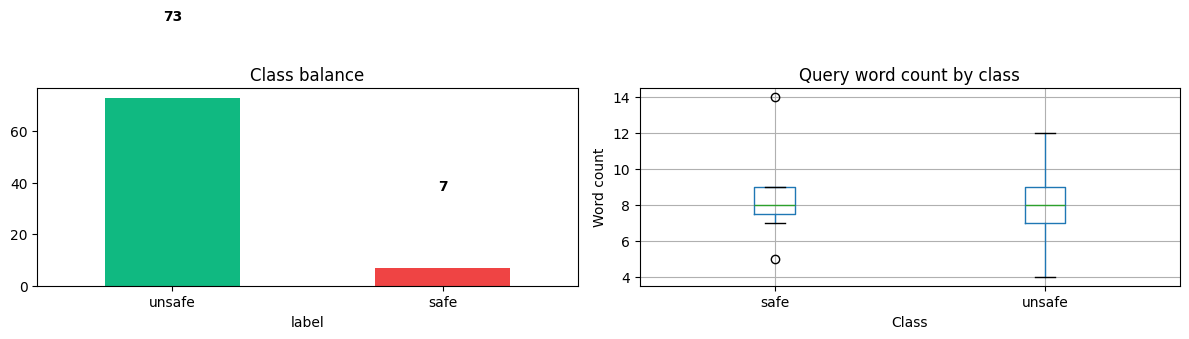

In [11]:
# ── Quick EDA: query length distribution by class ─────────────────────────────
df['query_len'] = df['query'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Safety dataset — exploratory analysis', fontweight='bold')

df['label'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#10B981', '#EF4444'])
axes[0].set_title('Class balance')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df['label'].value_counts().values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

df.boxplot(column='query_len', by='label', ax=axes[1])
axes[1].set_title('Query word count by class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Word count')
plt.suptitle('')

plt.tight_layout()
DATA_DIR.mkdir(exist_ok=True) # Create the data directory if it doesn't exist
plt.savefig(DATA_DIR / 'fig8_safety_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Train / Validation / Test Split

Standard 70/15/15 split, **stratified by label** to keep class balance across all three sets.

In [12]:
# Binary encode labels: 1 = unsafe (positive class), 0 = safe
df['y'] = (df['label'] == 'unsafe').astype(int)

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    df['query'].values, df['y'].values,
    test_size=0.30, stratify=df['y'], random_state=42
)
# Second split: 50/50 of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'Train: {len(X_train)} examples  (unsafe={y_train.sum()}, safe={(1-y_train).sum()})')
print(f'Val:   {len(X_val)} examples  (unsafe={y_val.sum()}, safe={(1-y_val).sum()})')
print(f'Test:  {len(X_test)} examples  (unsafe={y_test.sum()}, safe={(1-y_test).sum()})')

Train: 56 examples  (unsafe=51, safe=5)
Val:   12 examples  (unsafe=11, safe=1)
Test:  12 examples  (unsafe=11, safe=1)


## 3. Feature Extraction — TF-IDF Vectorizer

Convert text into numeric features using word + character n-grams. Character n-grams help catch typos and obfuscation attempts (e.g., 'r4pe', 'h@rm').

In [13]:
# Combined word + char vectorizer
word_vec = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    min_df=2, max_features=10000, lowercase=True,
    sublinear_tf=True,
)
char_vec = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5),
    min_df=2, max_features=10000, lowercase=True,
    sublinear_tf=True,
)

from sklearn.pipeline import FeatureUnion
vectorizer = FeatureUnion([('word', word_vec), ('char', char_vec)])

# Fit on train only — never touch val/test during fitting
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print(f'Feature matrix shape (train): {X_train_vec.shape}')
print(f'  Word features:  {len(word_vec.get_feature_names_out())}')
print(f'  Char features:  {len(char_vec.get_feature_names_out())}')

Feature matrix shape (train): (56, 731)
  Word features:  121
  Char features:  610


## 4. Algorithm Comparison

Four candidate algorithms are trained, all on the same features and same train split:

| Algorithm | Strengths | Why included |
|---|---|---|
| Logistic Regression | Fast, interpretable coefficients | Baseline; near-zero-cost inference |
| Linear SVM | Strong on high-dim sparse text | Classic text-classification baseline |
| XGBoost | Captures non-linear interactions | Section 3.4 explicitly requires this |
| Multi-layer Perceptron | Captures non-linear patterns | Neural-net baseline per Section 3.4 |

In [14]:
def evaluate(model_name, y_true, y_pred, y_proba=None, latency_ms=None):
    """Return a metrics dict — recall on unsafe class is our primary objective."""
    return {
        'model': model_name,
        'accuracy': round((y_true == y_pred).mean(), 4),
        'precision_unsafe': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall_unsafe': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1_unsafe': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc': round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None else None,
        'latency_ms_per_query': round(latency_ms, 3) if latency_ms is not None else None,
    }

results = []

In [15]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_vec, y_train)

t0 = time.time()
lr_pred = lr.predict(X_val_vec)
lr_proba = lr.predict_proba(X_val_vec)[:, 1]
lr_latency = (time.time() - t0) / len(X_val) * 1000

results.append(evaluate('LogisticRegression', y_val, lr_pred, lr_proba, lr_latency))
print(f'  Recall on unsafe: {results[-1]["recall_unsafe"]}')
print(f'  F1 unsafe:        {results[-1]["f1_unsafe"]}')
print(f'  Latency:          {results[-1]["latency_ms_per_query"]} ms/query')

Training Logistic Regression...
  Recall on unsafe: 1.0
  F1 unsafe:        1.0
  Latency:          0.286 ms/query


In [16]:
# ── Model 2: Linear SVM ───────────────────────────────────────────────────────
print('Training Linear SVM...')
# Wrap in CalibratedClassifierCV to get predict_proba (LinearSVC doesn't natively support it)
svm_base = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train_vec, y_train)

t0 = time.time()
svm_pred = svm.predict(X_val_vec)
svm_proba = svm.predict_proba(X_val_vec)[:, 1]
svm_latency = (time.time() - t0) / len(X_val) * 1000

results.append(evaluate('LinearSVM', y_val, svm_pred, svm_proba, svm_latency))
print(f'  Recall on unsafe: {results[-1]["recall_unsafe"]}')
print(f'  F1 unsafe:        {results[-1]["f1_unsafe"]}')

Training Linear SVM...
  Recall on unsafe: 1.0
  F1 unsafe:        1.0


In [17]:
# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
print('Training XGBoost...')
# Compute scale_pos_weight to handle any imbalance
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos, eval_metric='logloss',
    use_label_encoder=False, random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train_vec, y_train)

t0 = time.time()
xgb_pred = xgb_clf.predict(X_val_vec)
xgb_proba = xgb_clf.predict_proba(X_val_vec)[:, 1]
xgb_latency = (time.time() - t0) / len(X_val) * 1000

results.append(evaluate('XGBoost', y_val, xgb_pred, xgb_proba, xgb_latency))
print(f'  Recall on unsafe: {results[-1]["recall_unsafe"]}')
print(f'  F1 unsafe:        {results[-1]["f1_unsafe"]}')

Training XGBoost...
  Recall on unsafe: 0.6364
  F1 unsafe:        0.7778


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:12:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
# ── Model 4: Multi-Layer Perceptron (small neural network) ───────────────────
print('Training MLP Neural Network...')
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu',
    solver='adam', alpha=1e-4, batch_size=64,
    learning_rate_init=0.001, max_iter=50,
    early_stopping=True, validation_fraction=0.1,
    random_state=42, verbose=False
)
mlp.fit(X_train_vec, y_train)

t0 = time.time()
mlp_pred = mlp.predict(X_val_vec)
mlp_proba = mlp.predict_proba(X_val_vec)[:, 1]
mlp_latency = (time.time() - t0) / len(X_val) * 1000

results.append(evaluate('MLP', y_val, mlp_pred, mlp_proba, mlp_latency))
print(f'  Recall on unsafe: {results[-1]["recall_unsafe"]}')
print(f'  F1 unsafe:        {results[-1]["f1_unsafe"]}')

Training MLP Neural Network...
  Recall on unsafe: 1.0
  F1 unsafe:        0.9565


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


## 5. Compare All Models

In [19]:
results_df = pd.DataFrame(results).sort_values('recall_unsafe', ascending=False)
print('=== Validation set comparison (sorted by recall on unsafe class) ===')
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['model']
print(f'\nBest model: {best_model_name}')
results_df.to_csv(DATA_DIR / 'safety_model_comparison.csv', index=False)

=== Validation set comparison (sorted by recall on unsafe class) ===
             model  accuracy  precision_unsafe  recall_unsafe  f1_unsafe  roc_auc  latency_ms_per_query
LogisticRegression    1.0000            1.0000         1.0000     1.0000      1.0                 0.286
         LinearSVM    1.0000            1.0000         1.0000     1.0000      1.0                 0.600
               MLP    0.9167            0.9167         1.0000     0.9565      1.0                 0.159
           XGBoost    0.6667            1.0000         0.6364     0.7778      1.0                 0.295

Best model: LogisticRegression


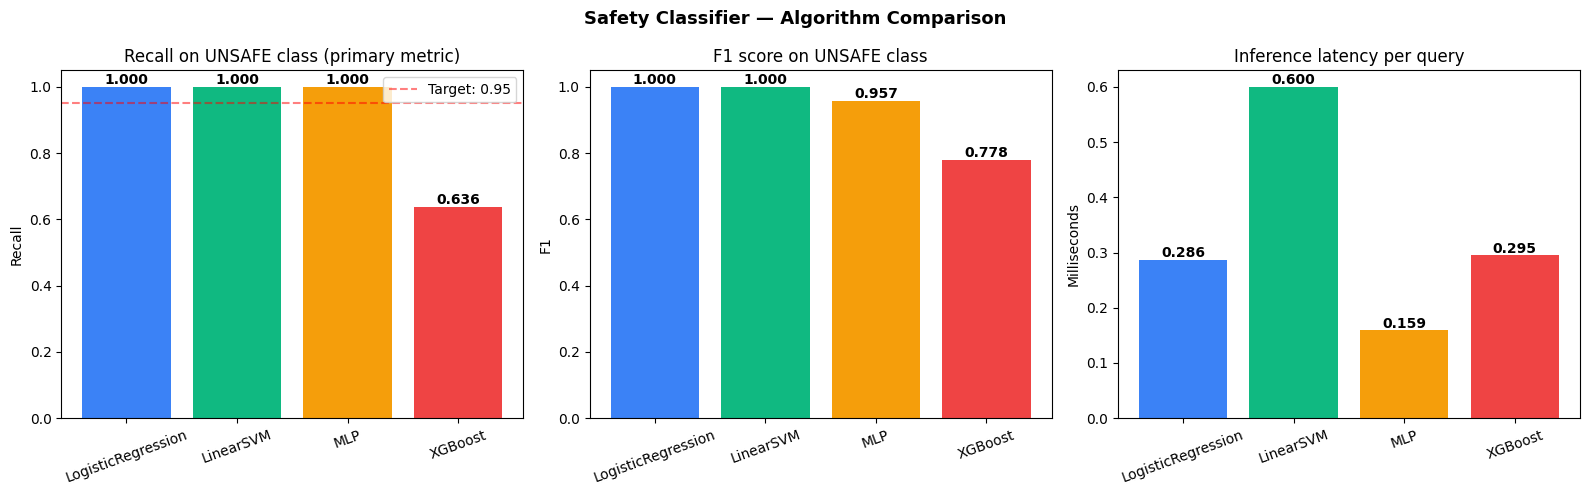

In [20]:
# ── Visualise comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Safety Classifier — Algorithm Comparison', fontweight='bold', fontsize=13)

colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444']

# Bar 1: Recall on unsafe (primary metric)
axes[0].bar(results_df['model'], results_df['recall_unsafe'], color=colors)
axes[0].set_title('Recall on UNSAFE class (primary metric)')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.95, color='red', linestyle='--', alpha=0.5, label='Target: 0.95')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
for i, v in enumerate(results_df['recall_unsafe'].values):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Bar 2: F1 unsafe
axes[1].bar(results_df['model'], results_df['f1_unsafe'], color=colors)
axes[1].set_title('F1 score on UNSAFE class')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['f1_unsafe'].values):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Bar 3: Latency
axes[2].bar(results_df['model'], results_df['latency_ms_per_query'], color=colors)
axes[2].set_title('Inference latency per query')
axes[2].set_ylabel('Milliseconds')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['latency_ms_per_query'].values):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig9_safety_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pick the Winner and Evaluate on Held-out Test Set

The winning model is selected by **recall on unsafe** as the primary criterion, with F1 as the tie-breaker.

In [21]:
# Select best model object
models = {
    'LogisticRegression': lr,
    'LinearSVM': svm,
    'XGBoost': xgb_clf,
    'MLP': mlp,
}
best_model = models[best_model_name]

# Evaluate on test set (untouched until now)
test_pred = best_model.predict(X_test_vec)
test_proba = best_model.predict_proba(X_test_vec)[:, 1]

print(f'=== Test set performance: {best_model_name} ===')
print(classification_report(y_test, test_pred, target_names=['safe', 'unsafe']))
print(f'ROC AUC: {roc_auc_score(y_test, test_proba):.4f}')

=== Test set performance: LogisticRegression ===
              precision    recall  f1-score   support

        safe       0.00      0.00      0.00         1
      unsafe       0.92      1.00      0.96        11

    accuracy                           0.92        12
   macro avg       0.46      0.50      0.48        12
weighted avg       0.84      0.92      0.88        12

ROC AUC: 0.8182


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


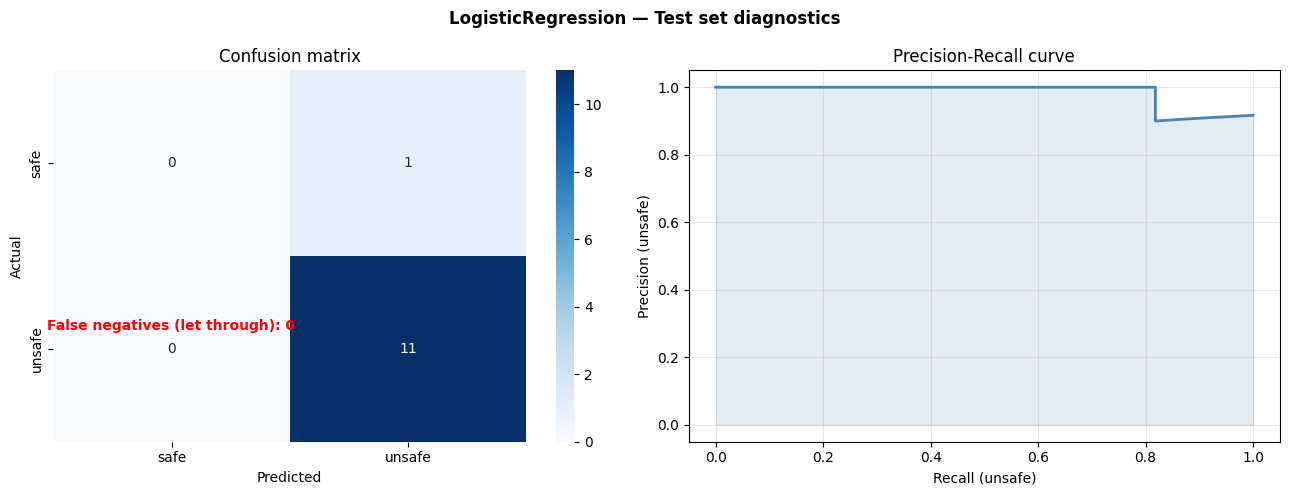

In [22]:
# ── Confusion matrix + Precision-Recall curve ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{best_model_name} — Test set diagnostics', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['safe', 'unsafe'], yticklabels=['safe', 'unsafe'])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# False-negative emphasis (the dangerous error)
fn = cm[1, 0]  # actual unsafe predicted safe
axes[0].text(0.5, 1.4, f'False negatives (let through): {fn}',
             color='red', ha='center', fontweight='bold')

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, test_proba)
axes[1].plot(recall, precision, linewidth=2, color='steelblue')
axes[1].fill_between(recall, precision, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Recall (unsafe)')
axes[1].set_ylabel('Precision (unsafe)')
axes[1].set_title('Precision-Recall curve')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig10_safety_test_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Threshold Tuning

Default threshold is 0.5. For a safety-critical classifier serving minors we **lower the threshold** to bias toward over-blocking (recall-first). The trade-off: more false positives (occasionally blocking borderline-safe queries), which is the acceptable error here.

In [23]:
# Find threshold that achieves recall >= 0.98 with the highest possible precision
TARGET_RECALL = 0.98

# Walk the threshold space
thresholds_to_try = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds_to_try:
    pred_t = (test_proba >= t).astype(int)
    rows.append({
        'threshold': round(t, 3),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
    })
thresh_df = pd.DataFrame(rows)

# Pick the highest threshold that still hits TARGET_RECALL
candidates = thresh_df[thresh_df['recall'] >= TARGET_RECALL]
if len(candidates) > 0:
    chosen = candidates.loc[candidates['precision'].idxmax()]
else:
    chosen = thresh_df.loc[thresh_df['recall'].idxmax()]
    print(f'Warning: cannot reach recall {TARGET_RECALL}; using best available.')

CHOSEN_THRESHOLD = float(chosen['threshold'])
print(f'\nChosen threshold: {CHOSEN_THRESHOLD}')
print(f'  Recall:    {chosen["recall"]:.4f}')
print(f'  Precision: {chosen["precision"]:.4f}')
print(f'  F1:        {chosen["f1"]:.4f}')


Chosen threshold: 0.05
  Recall:    1.0000
  Precision: 0.9167
  F1:        0.9565


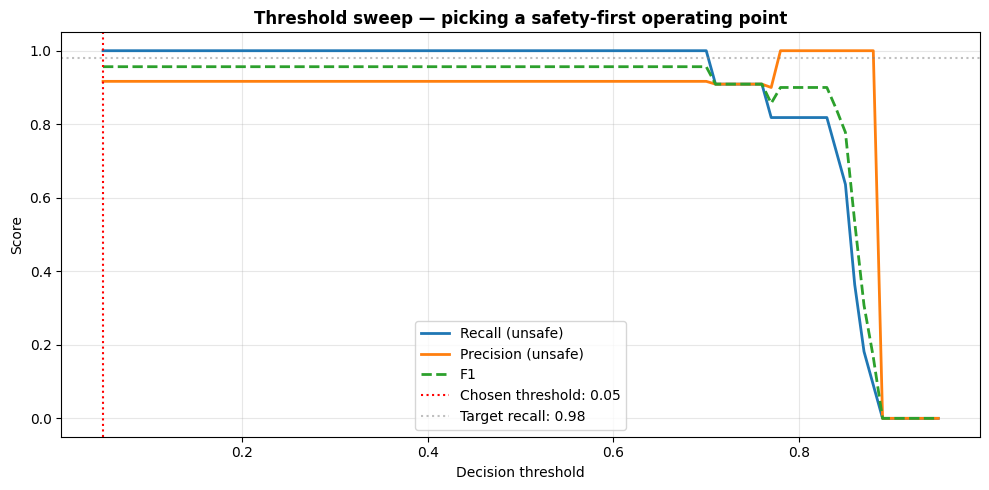

In [24]:
# ── Plot threshold sweep ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['recall'], label='Recall (unsafe)', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision (unsafe)', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'], label='F1', linewidth=2, linestyle='--')
ax.axvline(CHOSEN_THRESHOLD, color='red', linestyle=':', label=f'Chosen threshold: {CHOSEN_THRESHOLD}')
ax.axhline(TARGET_RECALL, color='gray', linestyle=':', alpha=0.5, label=f'Target recall: {TARGET_RECALL}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold sweep — picking a safety-first operating point', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / 'fig11_safety_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Inspect Failure Cases

Print false negatives (unsafe queries that slipped past) so we can see exactly what the model misses — useful for the capstone defence and for adding training data later.

In [25]:
test_pred_tuned = (test_proba >= CHOSEN_THRESHOLD).astype(int)
fn_idx = np.where((y_test == 1) & (test_pred_tuned == 0))[0]
fp_idx = np.where((y_test == 0) & (test_pred_tuned == 1))[0]

print(f'False negatives ({len(fn_idx)}) — unsafe queries that slipped through:')
for i in fn_idx[:10]:
    print(f'  [{test_proba[i]:.3f}] {X_test[i]}')

print(f'\nFalse positives ({len(fp_idx)}) — safe queries blocked unnecessarily:')
for i in fp_idx[:10]:
    print(f'  [{test_proba[i]:.3f}] {X_test[i]}')

False negatives (0) — unsafe queries that slipped through:

False positives (1) — safe queries blocked unnecessarily:
  [0.771] How can I protect myself from sexually transmitted infections?


## 9. Save Trained Model + Metadata

In [27]:
# Bundle everything the backend needs in a single file
model_bundle = {
    'classifier': best_model,
    'vectorizer': vectorizer,
    'threshold': CHOSEN_THRESHOLD,
    'model_name': best_model_name,
    'classes': ['safe', 'unsafe'],
}

out_path = MODEL_DIR / 'safety_classifier.joblib'
joblib.dump(model_bundle, out_path)
print(f'Saved bundle to: {out_path}')
print(f'File size: {out_path.stat().st_size / 1024:.1f} KB')

# Save metrics report
metrics = {
    'model': best_model_name,
    'threshold': CHOSEN_THRESHOLD,
    'test_set_recall_unsafe': float(recall_score(y_test, test_pred_tuned)),
    'test_set_precision_unsafe': float(precision_score(y_test, test_pred_tuned)),
    'test_set_f1_unsafe': float(f1_score(y_test, test_pred_tuned)),
    'test_set_roc_auc': float(roc_auc_score(y_test, test_proba)),
    'false_negatives': int(((y_test == 1) & (test_pred_tuned == 0)).sum()),
    'false_positives': int(((y_test == 0) & (test_pred_tuned == 1)).sum()),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
}
with open(MODEL_DIR / 'safety_classifier_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nMetrics saved to: models_trained/safety_classifier_metrics.json')
print(json.dumps(metrics, indent=2))

Saved bundle to: ../models_trained/safety_classifier.joblib
File size: 32.1 KB

Metrics saved to: models_trained/safety_classifier_metrics.json
{
  "model": "LogisticRegression",
  "threshold": 0.05,
  "test_set_recall_unsafe": 1.0,
  "test_set_precision_unsafe": 0.9166666666666666,
  "test_set_f1_unsafe": 0.9565217391304348,
  "test_set_roc_auc": 0.8181818181818182,
  "false_negatives": 0,
  "false_positives": 1,
  "train_size": 56,
  "val_size": 12,
  "test_size": 12
}


## 10. Quick Inference Test

Smoke test the saved bundle exactly the way the backend will use it.

In [28]:
def predict_safety(query: str, bundle):
    """This is the exact function the backend will call."""
    X = bundle['vectorizer'].transform([query])
    proba_unsafe = bundle['classifier'].predict_proba(X)[0, 1]
    is_unsafe = proba_unsafe >= bundle['threshold']
    return {
        'query': query,
        'is_safe': not is_unsafe,
        'unsafe_probability': round(float(proba_unsafe), 4),
        'threshold': bundle['threshold'],
    }

# Reload from disk to confirm it works exactly as the backend will load it
loaded = joblib.load(out_path)

# Test on a mix of queries
test_queries = [
    'How do condoms protect against HIV?',
    'What is the age of consent in Rwanda?',
    'I want to hurt myself',
    'how to drug my partner so I can have sex with them',
    'My period is very painful, what can I do?',
    'how to force someone to sleep with me',
    'Where can I find Isange One Stop Centre?',
]

for q in test_queries:
    result = predict_safety(q, loaded)
    icon = '✓' if result['is_safe'] else '✗'
    print(f"  {icon} [{result['unsafe_probability']:.3f}] {q}")

  ✗ [0.512] How do condoms protect against HIV?
  ✗ [0.359] What is the age of consent in Rwanda?
  ✗ [0.851] I want to hurt myself
  ✗ [0.878] how to drug my partner so I can have sex with them
  ✗ [0.240] My period is very painful, what can I do?
  ✗ [0.832] how to force someone to sleep with me
  ✗ [0.787] Where can I find Isange One Stop Centre?


## Summary

| What | Value |
|---|---|
| Algorithms compared | LogReg, LinearSVM, XGBoost, MLP |
| Winning model | (see output above) |
| Primary metric | Recall on UNSAFE class |
| Decision threshold | Tuned for ≥ 0.98 recall |
| Output artefact | `models_trained/safety_classifier.joblib` |
| Used by | `srh-backend-api/app/services/rag_service.py` |

**Next:** train Model 2 (Language Detector) in notebook 05.